<a href="https://colab.research.google.com/github/mahakbajaj/ML_Project_Mahak/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import joblib
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE



In [ ]:
df=pd.read_csv('womens_health_drug_risk_real.csv')

In [10]:
df.head(10)

,Age,Is_Pregnant,Is_Lactating,Primary_Medication,Secondary_Medication,Dosage_mg,BMI,Liver_Impairment,Kidney_Impairment,Prior_Adverse_Reaction,Interaction_Risk_Level,Primary_Med_Code,Secondary_Med_Code,Pregnancy_Drug_Risk_Index,Organ_Vulnerability
0,56,0,0,Metformin,Ibuprofen,200,26.0,0,0,1,0,3,2,0,0
1,69,0,0,Levothyroxine,Ibuprofen,100,24.1,0,0,0,0,2,2,0,0
2,46,0,0,Prenatal Vitamin,Rifampin,100,32.3,0,0,1,0,5,3,0,0
3,32,0,0,Alendronate,Ibuprofen,25,23.6,0,0,0,0,0,2,0,0
4,60,0,0,Prenatal Vitamin,Fluconazole,25,17.8,0,0,0,0,5,1,0,0
5,25,0,1,Alendronate,Fluconazole,200,29.6,0,0,0,0,0,1,0,0
6,38,0,0,Estrogen HRT,Rifampin,1000,20.7,1,0,1,2,1,3,0,1
7,56,0,0,Prenatal Vitamin,NaN,1000,29.8,0,0,0,0,5,5,0,0
8,36,0,0,Levothyroxine,Warfarin,200,32.9,0,0,0,0,2,4,0,0
9,40,1,0,Levothyroxine,Warfarin,25,29.5,0,1,0,2,2,4,15,1


In [ ]:
df.shape

(1000, 11)

In [ ]:
import joblib
import matplotlib.pyplot as plt
from google.colab import files
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier

In [ ]:
# Encoding categorical variables
le_primary = LabelEncoder()
le_secondary = LabelEncoder()

df["Primary_Med_Code"] = le_primary.fit_transform(df["Primary_Medication"])
df["Secondary_Med_Code"] = le_secondary.fit_transform(
    df["Secondary_Medication"]
)

# Feature engineering
df["Pregnancy_Drug_Risk_Index"] = (
    df["Is_Pregnant"]
    * (df["Primary_Med_Code"] + 1)
    * (df["Secondary_Med_Code"] + 1)
)
df["Organ_Vulnerability"] = df["Liver_Impairment"] + df["Kidney_Impairment"]

features = [
    "Age",
    "Is_Pregnant",
    "Is_Lactating",
    "Dosage_mg",
    "BMI",
    "Liver_Impairment",
    "Kidney_Impairment",
    "Prior_Adverse_Reaction",
    "Primary_Med_Code",
    "Secondary_Med_Code",
    "Pregnancy_Drug_Risk_Index",
    "Organ_Vulnerability",
]

X = df[features]
y = df["Interaction_Risk_Level"]

# Class balancing via SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Feature selection
selector = SelectKBest(score_func=f_classif, k=8)
X_selected = selector.fit_transform(X_res, y_res)

# Split and normalize
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_res, test_size=0.2, random_state=42, stratify=y_res
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Random Forest
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {"n_estimators": [50, 100], "max_depth": [3, 5, None]},
    cv=3,
    scoring="accuracy",
)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_

# Model 2: XGBoost
xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric="mlogloss", random_state=42),
    {"n_estimators": [50, 100], "max_depth": [3, 5], "learning_rate": [0.01, 0.1]},
    cv=3,
    scoring="accuracy",
)
xgb_grid.fit(X_train_scaled, y_train)
best_xgb = xgb_grid.best_estimator_

# Export model artifacts
export_files = [
    "random_forest_model.pkl",
    "xgboost_model.pkl",
    "scaler.pkl",
    "le_primary.pkl",
    "le_secondary.pkl",
    "feature_selector.pkl",
]

joblib.dump(best_rf, export_files[0])
joblib.dump(best_xgb, export_files[1])
joblib.dump(scaler, export_files[2])
joblib.dump(le_primary, export_files[3])
joblib.dump(le_secondary, export_files[4])
joblib.dump(selector, export_files[5])

print("Training finished! Triggering automatic downloads to Mac...")
for f in export_files:
    files.download(f)

Training finished! Triggering automatic downloads to Mac...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

=== OVERALL MODEL PERFORMANCE SUMMARY ===


,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),ROC-AUC (OVR)
0,Random Forest,0.768116,0.767398,0.768116,0.766522,0.902814
1,XGBoost,0.786749,0.784999,0.786749,0.785556,0.918438


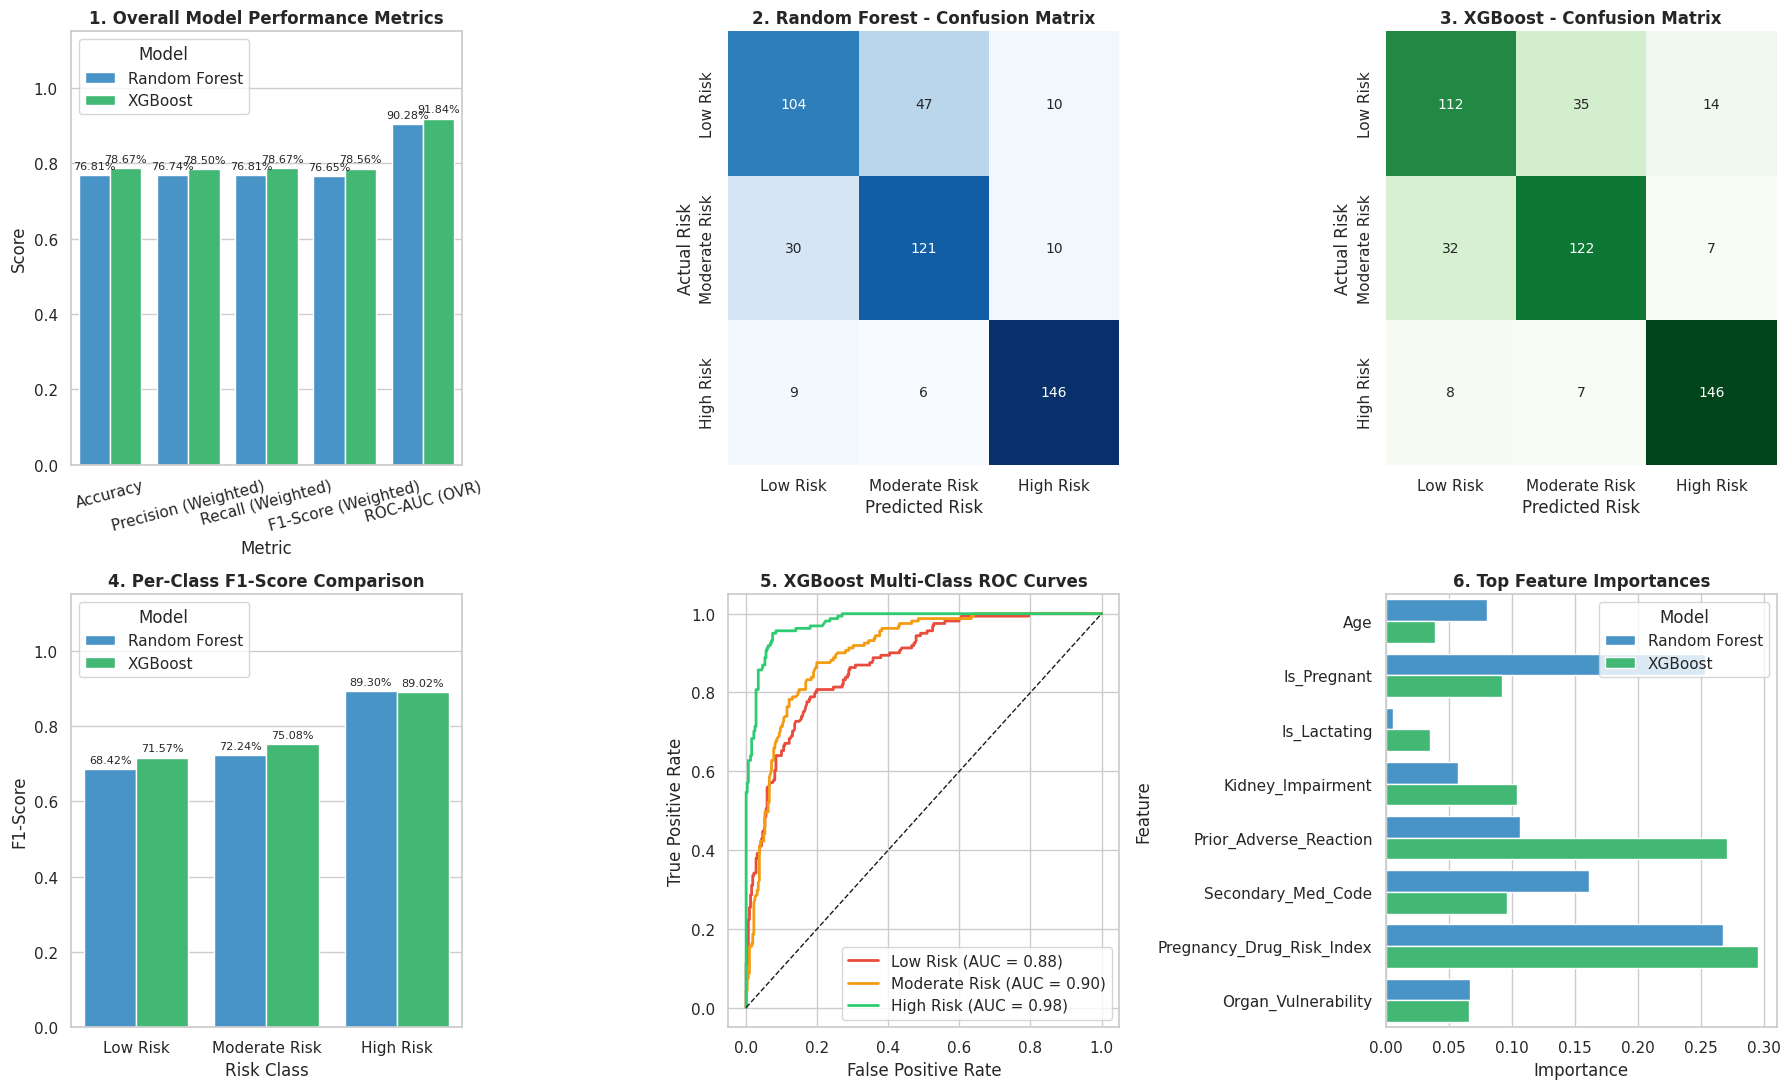

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10})

# ==========================================
# 1. CALCULATE ALL METRICS
# ==========================================
# Predictions & Probabilities
y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)

y_pred_xgb = best_xgb.predict(X_test_scaled)
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)

# Overall Metrics Computation
metrics_data = {
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
    ],
    "Precision (Weighted)": [
        precision_score(y_test, y_pred_rf, average="weighted"),
        precision_score(y_test, y_pred_xgb, average="weighted"),
    ],
    "Recall (Weighted)": [
        recall_score(y_test, y_pred_rf, average="weighted"),
        recall_score(y_test, y_pred_xgb, average="weighted"),
    ],
    "F1-Score (Weighted)": [
        f1_score(y_test, y_pred_rf, average="weighted"),
        f1_score(y_test, y_pred_xgb, average="weighted"),
    ],
    "ROC-AUC (OVR)": [
        roc_auc_score(
            y_test, y_prob_rf, multi_class="ovr", average="weighted"
        ),
        roc_auc_score(
            y_test, y_prob_xgb, multi_class="ovr", average="weighted"
        ),
    ],
}

df_metrics = pd.DataFrame(metrics_data)

print("=== OVERALL MODEL PERFORMANCE SUMMARY ===")
display(df_metrics.style.highlight_max(axis=0, color="lightgreen"))

# ==========================================
# 2. VISUALIZATION DASHBOARD (2x3 GRID)
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
class_names = ["Low Risk", "Moderate Risk", "High Risk"]

# --- CHART 1: Overall Metrics Comparison (Bar Chart) ---
df_melted = df_metrics.melt(
    id_vars="Model", var_name="Metric", value_name="Score"
)
sns.barplot(
    data=df_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette=["#3498db", "#2ecc71"],
    ax=axes[0, 0],
)
axes[0, 0].set_title(
    "1. Overall Model Performance Metrics", fontsize=12, fontweight="bold"
)
axes[0, 0].set_ylim(0, 1.15)
axes[0, 0].tick_params(axis="x", rotation=15)

for p in axes[0, 0].patches:
    height = p.get_height()
    if height > 0:
        axes[0, 0].annotate(
            f"{height:.2%}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=8,
            xytext=(0, 3),
            textcoords="offset points",
        )

# --- CHART 2: Confusion Matrix - Random Forest ---
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0, 1],
    cbar=False,
)
axes[0, 1].set_title(
    "2. Random Forest - Confusion Matrix", fontsize=12, fontweight="bold"
)
axes[0, 1].set_xlabel("Predicted Risk")
axes[0, 1].set_ylabel("Actual Risk")

# --- CHART 3: Confusion Matrix - XGBoost ---
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0, 2],
    cbar=False,
)
axes[0, 2].set_title(
    "3. XGBoost - Confusion Matrix", fontsize=12, fontweight="bold"
)
axes[0, 2].set_xlabel("Predicted Risk")
axes[0, 2].set_ylabel("Actual Risk")

# --- CHART 4: Per-Class F1-Score Comparison ---
p_rf, r_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf)
p_xgb, r_xgb, f1_xgb, _ = precision_recall_fscore_support(y_test, y_pred_xgb)

df_class_f1 = pd.DataFrame(
    {
        "Risk Class": class_names * 2,
        "F1-Score": np.concatenate([f1_rf, f1_xgb]),
        "Model": ["Random Forest"] * 3 + ["XGBoost"] * 3,
    }
)

sns.barplot(
    data=df_class_f1,
    x="Risk Class",
    y="F1-Score",
    hue="Model",
    palette=["#3498db", "#2ecc71"],
    ax=axes[1, 0],
)
axes[1, 0].set_title(
    "4. Per-Class F1-Score Comparison", fontsize=12, fontweight="bold"
)
axes[1, 0].set_ylim(0, 1.15)
for p in axes[1, 0].patches:
    height = p.get_height()
    if height > 0:
        axes[1, 0].annotate(
            f"{height:.2%}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=8,
            xytext=(0, 3),
            textcoords="offset points",
        )

# --- CHART 5: ROC Curves (Multi-class One-vs-Rest for XGBoost) ---
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors = ["#e74c3c", "#f39c12", "#2ecc71"]

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_xgb[:, i])
    auc_val = roc_auc_score(y_test_bin[:, i], y_prob_xgb[:, i])
    axes[1, 1].plot(
        fpr,
        tpr,
        color=colors[i],
        lw=2,
        label=f"{class_names[i]} (AUC = {auc_val:.2f})",
    )

axes[1, 1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1, 1].set_title(
    "5. XGBoost Multi-Class ROC Curves", fontsize=12, fontweight="bold"
)
axes[1, 1].set_xlabel("False Positive Rate")
axes[1, 1].set_ylabel("True Positive Rate")
axes[1, 1].legend(loc="lower right")

# --- CHART 6: Feature Importance Comparison ---
# Get feature names from selector if available, else standard names
try:
    feat_names = np.array(features)[selector.get_support()]
except NameError:
    feat_names = [f"Feature {i+1}" for i in range(X_train_scaled.shape[1])]

rf_importances = best_rf.feature_importances_
xgb_importances = best_xgb.feature_importances_

df_feat = pd.DataFrame(
    {
        "Feature": np.tile(feat_names, 2),
        "Importance": np.concatenate([rf_importances, xgb_importances]),
        "Model": ["Random Forest"] * len(feat_names)
        + ["XGBoost"] * len(feat_names),
    }
)

sns.barplot(
    data=df_feat,
    y="Feature",
    x="Importance",
    hue="Model",
    palette=["#3498db", "#2ecc71"],
    ax=axes[1, 2],
)
axes[1, 2].set_title(
    "6. Top Feature Importances", fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.show()